In [20]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# reproducibility
tf.random.set_seed(42)
np.random.seed(42)


In [22]:
train_dir = '/content/drive/MyDrive/Colab Notebooks/plant Diseases Prediction/Train/Train'
val_dir   = '/content/drive/MyDrive/Colab Notebooks/plant Diseases Prediction/Validation/Validation'
test_dir  = '/content/drive/MyDrive/Colab Notebooks/plant Diseases Prediction/Test/Test'

IMG_SIZE = 224
BATCH_SIZE = 32


In [23]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

labels = list(train_gen.class_indices.keys())
print("Classes:", labels)


Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 150 images belonging to 3 classes.
Classes: ['Healthy', 'Powdery', 'Rust']


In [24]:
import tensorflow as tf
print("GPU AVAILABLE :",tf.config.list_physical_devices('GPU'))

GPU AVAILABLE : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
y = train_gen.classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.9621542940320232), 1: np.float64(1.0248062015503876), 2: np.float64(1.0153609831029187)}


In [26]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
outputs = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [27]:
checkpoint_path = '/content/drive/MyDrive/efficientnetb0_best.h5'
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]


In [28]:
EPOCHS_HEAD = 15

history = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4265 - loss: 1.0704
Epoch 1: val_accuracy improved from -inf to 0.73333, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.4272 - loss: 1.0694 - val_accuracy: 0.7333 - val_loss: 0.8603 - learning_rate: 1.0000e-04
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5621 - loss: 0.9238
Epoch 2: val_accuracy improved from 0.73333 to 0.86667, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.5626 - loss: 0.9232 - val_accuracy: 0.8667 - val_loss: 0.7409 - learning_rate: 1.0000e-04
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6583 - loss: 0.8182
Epoch 3: val_accuracy improved from 0.86667 to 0.90000, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.6585 - loss: 0.8179 - val_accuracy: 0.9000 - val_loss: 0.6392 - learning_rate: 1.0000e-04
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7415 - loss: 0.7294
Epoch 4: val_accuracy improved from 0.90000 to 0.91667, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.7419 - loss: 0.7289 - val_accuracy: 0.9167 - val_loss: 0.5631 - learning_rate: 1.0000e-04
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7904 - loss: 0.6583
Epoch 5: val_accuracy did not improve from 0.91667
42/42 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.7905 - loss: 0.6579 - val_accuracy: 0.9167 - val_loss: 0.5009 - learning_rate: 1.0000e-04
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8374 - loss: 0.5866
Epoch 6: val_accuracy improved from 0.91667 to 0.93333, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.8375 - loss: 0.5864 - val_accuracy: 0.9333 - val_loss: 0.4520 - learning_rate: 1.0000e-04
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8530 - loss: 0.5413
Epoch 7: val_accuracy improved from 0.93333 to 0.96667, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.8528 - loss: 0.5414 - val_accuracy: 0.9667 - val_loss: 0.4118 - learning_rate: 1.0000e-04
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8696 - loss: 0.5017
Epoch 8: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8697 - loss: 0.5014 - val_accuracy: 0.9500 - val_loss: 0.3778 - learning_rate: 1.0000e-04
Epoch 9/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8415 - loss: 0.5032
Epoch 9: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8423 - loss: 0.5025 - val_accuracy: 0.9500 - val_loss: 0.3513 - learning_rate: 1.0000e-04
Epoch 10/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8836 - loss: 0.4490
Epoch 10: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8838 - loss: 0.4487 - val_accuracy: 0.9500 - val_loss: 0.3260 - learning_rate: 1.0000e-04
Epoch 11/15
42/42 ━━━━━

In [29]:
base_model.trainable = True
N = 50  # Top 50 layers unfreeze
for layer in base_model.layers[:-N]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FINE = 10
history_fine = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD + EPOCHS_FINE,
    initial_epoch=history.epoch[-1] + 1 if len(history.epoch) else 0,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 16/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7230 - loss: 0.6852
Epoch 16: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.7233 - loss: 0.6844 - val_accuracy: 0.9500 - val_loss: 0.2268 - learning_rate: 1.0000e-05
Epoch 17/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8135 - loss: 0.5122
Epoch 17: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8136 - loss: 0.5121 - val_accuracy: 0.9333 - val_loss: 0.2345 - learning_rate: 1.0000e-05
Epoch 18/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8633 - loss: 0.4674
Epoch 18: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8633 - loss: 0.4666 - val_accuracy: 0.9333 - val_loss: 0.2259 - learning_rate: 1.0000e-05
Epoch 19/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9040 - loss: 0.3867
Epoch 19: val_accuracy did not improve from 0.96667
42/42 ━━━━━━━━━━━━━━━━━━━━

42/42 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.9483 - loss: 0.2566 - val_accuracy: 0.9833 - val_loss: 0.1476 - learning_rate: 1.0000e-05
Epoch 23/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9533 - loss: 0.2517
Epoch 23: val_accuracy did not improve from 0.98333
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9534 - loss: 0.2512 - val_accuracy: 0.9833 - val_loss: 0.1337 - learning_rate: 1.0000e-05
Epoch 24/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9581 - loss: 0.2174
Epoch 24: val_accuracy improved from 0.98333 to 1.00000, saving model to /content/drive/MyDrive/efficientnetb0_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.9580 - loss: 0.2173 - val_accuracy: 1.0000 - val_loss: 0.1173 - learning_rate: 1.0000e-05
Epoch 25/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9654 - loss: 0.1837
Epoch 25: val_accuracy did not improve from 1.00000
42/42 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9655 - loss: 0.1837 - val_accuracy: 1.0000 - val_loss: 0.1046 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 25.


In [30]:
model.load_weights(checkpoint_path)

test_loss, test_acc = model.evaluate(test_gen)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.9415 - loss: 0.2465
Test loss: 0.1727, Test accuracy: 0.9600


4/5 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   

5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step


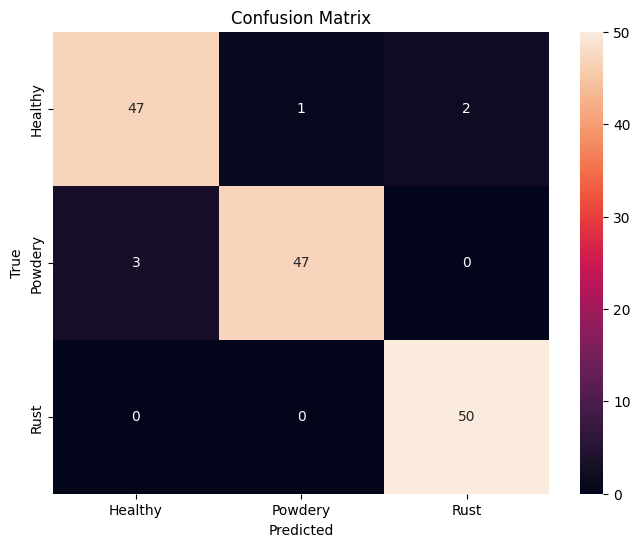

              precision    recall  f1-score   support

     Healthy       0.94      0.94      0.94        50
     Powdery       0.98      0.94      0.96        50
        Rust       0.96      1.00      0.98        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [31]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=labels))


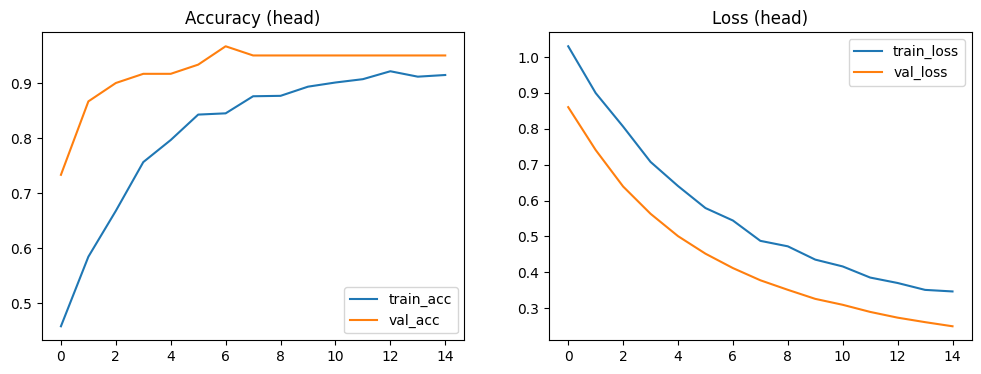

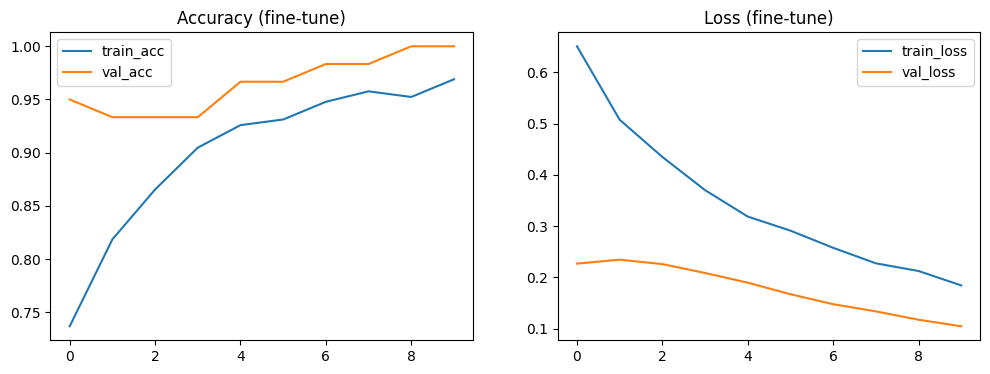

In [32]:
def plot_history(h, title_suffix=''):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.title('Accuracy ' + title_suffix)
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title('Loss ' + title_suffix)
    plt.legend()
    plt.show()

plot_history(history, '(head)')
plot_history(history_fine, '(fine-tune)')

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


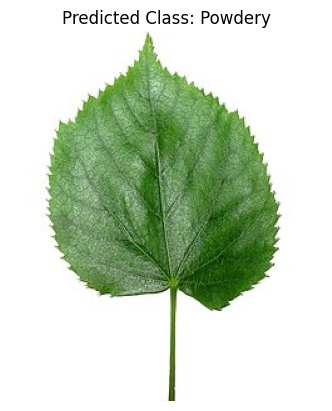

Prediction Probabilities:
Healthy: 0.3526
Powdery: 0.3621
Rust: 0.2853


In [33]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# Assuming the model is trained and loaded into the 'model' variable
# and 'labels' are defined from the training data generator.

def process_image(image_path, img_size=224):
    """Loads and preprocesses an image for prediction."""
    img = Image.open(image_path).resize((img_size, img_size))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)  # Use the same preprocess_input as for training
    return img_array

# Define the path to the image
image_path = '/content/drive/MyDrive/l2.jpg'  # Change this path to your image file

# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image not found at {image_path}. Please provide a valid path to your image file.")
else:
    # Load and preprocess the image
    processed_img_array = process_image(image_path, IMG_SIZE)

    # Load the original image for display
    original_img = Image.open(image_path)

    # Make a prediction using the trained model
    predictions = model.predict(processed_img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]

    # Get the class name from the labels list
    predicted_class_name = labels[predicted_class_index]

    # Display the original image and the predicted class
    plt.imshow(original_img)
    plt.title(f'Predicted Class: {predicted_class_name}')
    plt.axis('off')
    plt.show()

    # Print the confidence scores for each class
    print("Prediction Probabilities:")
    for i, prob in enumerate(predictions[0]):
        print(f"{labels[i]}: {prob:.4f}")

In [34]:
print(f"Training accuracy (head): {history.history['accuracy'][-1]:.4f}")
print(f"Validation accuracy (head): {history.history['val_accuracy'][-1]:.4f}")
print(f"Training accuracy (fine-tune): {history_fine.history['accuracy'][-1]:.4f}")
print(f"Validation accuracy (fine-tune): {history_fine.history['val_accuracy'][-1]:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Training accuracy (head): 0.9145
Validation accuracy (head): 0.9500
Training accuracy (fine-tune): 0.9690
Validation accuracy (fine-tune): 1.0000
Test accuracy: 0.9600
